# Stage D-E corrected evaluation
Uses the checkpoint FITS PSF, `model.eval()`, raw sparse mappings, and explicit zero-baseline skill.


In [1]:
from pathlib import Path
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import data
from differentiable_lensing import DifferentiableLensing
from psf import apply_psf, build_psf_kernel
from sisr import SISR
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CHECKPOINT=Path('outputs_corrected/mag_full/checkpoints/best.pt')
VAL_CLASS='no_sub'; VAL_INDEX=0


In [2]:
checkpoint=torch.load(CHECKPOINT,map_location=DEVICE)
args=checkpoint['args']
model=SISR(args['magnification'],args['n_mag'],args['residual_depth'],in_channels=2,latent_channel_count=args['latent_space_size']).to(DEVICE)
model.load_state_dict(checkpoint['model_state_dict']); model.eval()
lens=DifferentiableLensing(device=DEVICE,alpha=None,target_resolution=args['target_resolution'],target_shape=args['target_shape']).to(DEVICE)
root=Path(args.get('mapping_dir','.'))
forward=[torch.load(root/'scatter_to_log_128.pt',map_location=DEVICE).to(DEVICE),torch.load(root/'forward_from_log_128.pt',map_location=DEVICE).to(DEVICE),torch.load(root/'scatter_from_log_128.pt',map_location=DEVICE).to(DEVICE)]
backward=torch.load(root/'sparse_grid_fracs_euclid_backward.pt',map_location=DEVICE).to(DEVICE).coalesce()
idx,val=backward.indices(),backward.values().clamp_min(0); sums=torch.zeros(backward.shape[0],device=DEVICE); sums.scatter_add_(0,idx[0],val)
backward_avg=torch.sparse_coo_tensor(idx,val/sums[idx[0]].clamp_min(1e-8),backward.shape,device=DEVICE).coalesce()
psf=build_psf_kernel('fits',0.16,args['target_resolution'],path=args['psf_path'],source_pixscale_arcsec=args['psf_source_pixscale_arcsec'],device=DEVICE)


C:\Users\upraj\AppData\Local\Temp\ipykernel_20492\2375200876.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint=torch.load(CHECKPOINT,map_location=DEVICE)
C:\Use

zero MSE 0.006525034084916115 model MSE 0.0012540810275822878 skill 0.8078047037124634


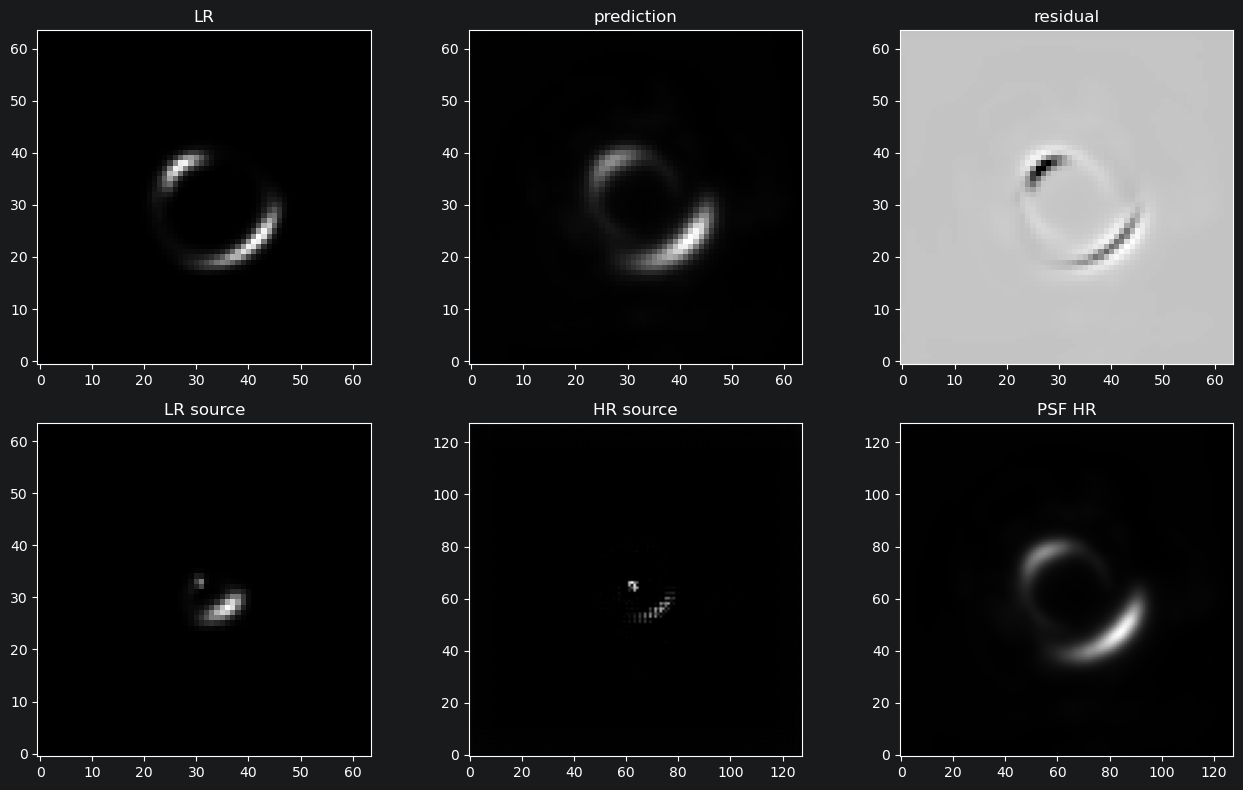

In [3]:
lr=data.LensingDataset('val/',[VAL_CLASS],args['val_samples_per_class'])[VAL_INDEX].unsqueeze(0).float().to(DEVICE)
lr=lr.unsqueeze(1) if lr.ndim==3 else lr
def sparse_apply(image,mapping,side):
    b,c,h,w=image.shape
    out=torch.sparse.mm(mapping,image.reshape(b*c,h*w).T)
    return out.T.reshape(b,c,side,side)
with torch.inference_mode():
    source_lr=sparse_apply(lr,backward_avg,args['image_shape'])
    source_hr=model(torch.cat([source_lr,lr],dim=1))
    intrinsic=lens.cross_grid_fill(source_hr,forward)
    psf_hr=apply_psf(intrinsic,psf)
    pred=F.interpolate(psf_hr,size=lr.shape[-2:],mode='area')
residual=pred-lr; zero_mse=lr.square().mean(); model_mse=F.mse_loss(pred,lr)
print('zero MSE',float(zero_mse),'model MSE',float(model_mse),'skill',float(1-model_mse/zero_mse.clamp_min(1e-8)))
fig,ax=plt.subplots(2,3,figsize=(13,8))
for a,t,x in zip(ax.flat,['LR','prediction','residual','LR source','HR source','PSF HR'],[lr[0,0],pred[0,0],residual[0,0],source_lr[0,0],source_hr[0,0],psf_hr[0,0]]):
    a.imshow(x.cpu(),origin='lower',cmap='gray'); a.set_title(t)
plt.tight_layout(); plt.show()
